In [ ]:
# DSC 550
# Week 6
# Fall 2024
# Final Project Milestone 1
# Created By Matthew Heinen
# 10/5/24

# Final Project Milestone 1
# Problem Introduction 

        The 2023 Minnesota Twins with the bases loaded only hit with a batting average of .143 nearly 100 points below league average. The 2024 season saw even worse results. At one point of the season the Twins had failed to score with runners in scoring position for over 30 plate appearances. The consistency and sample size of this problem is well known, and the answer is clear. The Twins have a clutch hitting problem.  

        As we reach the MLB post season, one in which the Twins missed after going on a 6-18 skid to end the season. A month of baseball that was marked by runners left on base, bad at bats, and absolutely no clutch hitting. 

        Moving into the offseason I plan to use this project as an exercise to identify potential candidates that are proven clutch hitters. Additionally, I hope to build models that can predict and project future successful clutch hitters. From these predictive models I hope go gather a selection of free agents that the Twins could look into acquiring in future seasons.  

        In this project I plan to build two models. The first being a multiple regression model that uses past hitting performance and other demographic statistics to predict the future success of hitters in clutch hitting situations, or situations with runners in scoring position. I plan to use the coeffecients from this regression equation to identify players that according to the model are likely to produce well in the clutch according to the model.  
 
    Secondly, I plan to build an unsupervised clustering model such as k-means clustering model to identify players that may carry the clutch gene or are likely to be good clutch hitters. By building these clusters I hope to identify both high performers but also some players who demographically show promise of being able to drive in runs in the clutch. The goal of creating these clusters it to hopefully identify some players that could be a bargain on the open market. Additionally, this model will help identify which players to stay away from. This feature may arguably be more important as the Minnesota Twins have no room for error bringing in players who are unable to hit with runners in scoring position.  

In [3]:
# Load data.

# Import packages
import pandas as pd

# File path 
file_path = 'RISP.csv'

# Read the .tsv file into a DataFrame
# Note you can use read_csv just need to change the separator to '/t'
df = pd.read_csv(file_path)

In [153]:
# Preview Dataframe
df


,pitches,player_id,player_name,year,total_pitches,pitch_percent,ba,iso,babip,slg,...,pos4_int_start_distance,pos5_int_start_distance,pos6_int_start_distance,pos7_int_start_distance,pos8_int_start_distance,pos9_int_start_distance,pitcher_run_exp,run_exp,bat_speed,swing_length
21,48,676391,"Clement, Ernie",2023,155,31.0,0.667,0.133,0.667,0.800,...,146,113,144,297,317,280,-7.3,7.3,NaN,NaN
22,19,647351,"Toro, Abraham",2023,69,27.5,0.667,0.500,0.600,1.167,...,144,106,150,303,322,298,-4.6,4.6,NaN,NaN
29,83,650333,"Arraez, Luis",2020,512,16.2,0.579,0.263,0.579,0.842,...,140,102,139,281,312,300,-8.8,8.8,NaN,NaN
30,41,595943,"Evans, Phillip",2020,159,25.8,0.556,0.444,0.571,1.000,...,149,112,144,297,309,282,-5.7,5.7,NaN,NaN
31,48,663967,"Salazar, César",2024,111,43.2,0.500,0.100,0.455,0.600,...,139,104,144,286,321,289,-2.0,2.0,62.289433,6.945704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,39,622608,"Senzatela, Antonio",2021,159,24.5,0.000,0.000,0.000,0.000,...,133,97,138,292,302,272,5.9,-5.9,NaN,NaN
3371,39,621532,"Bemboom, Anthony",2022,244,16.0,0.000,0.000,0.000,0.000,...,152,103,148,290,317,290,1.9,-1.9,NaN,NaN
3375,23,594988,"Schebler, Scott",2021,114,20.2,0.000,0.000,0.000,0.000,...,160,118,153,290,318,292,2.3,-2.3,NaN,NaN
3380,32,670370,"Young, Andrew",2020,145,22.1,0.000,0.000,0.000,0.000,...,151,115,145,295,316,290,2.8,-2.8,NaN,NaN


# Dataset Background. 

Our Dataset that we have found above contains hitting statistics from every player in major league baseball that has taken an at bat with runners in scoring position from the 2020 season on. We have chosen to evaluate players seasons from only 2020 and later for two reasons; First, We wish to only evaluate modern baseball, secondly we do not want to evaluate statistics form the 2019 season where MLB experimented with a baseball the flew further leading to inflated hitting stats. Our dataset contains 36 different hitting statistics from 3,412 different Players seasons. 

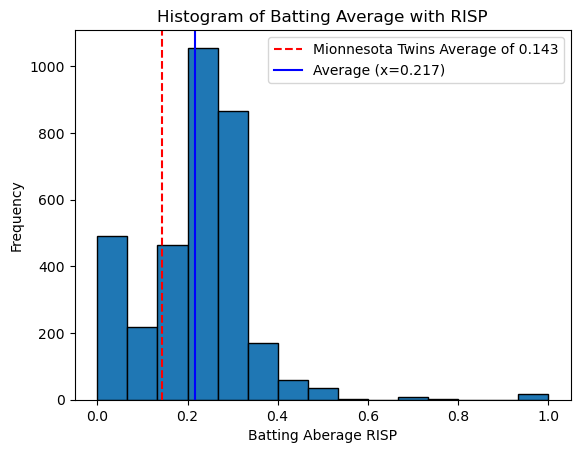

In [17]:
# Histogram of BA

# Import Packages
import matplotlib.pyplot as plt

# Calculate the average of the vatting average column
average_ba = df['ba'].mean()

# Build the histogram for the batting average column to evaluuate the batting average for RISP
plt.hist(df['ba'], bins=15, edgecolor='black')
# Twins Line
plt.axvline(x=0.143, color='red', linestyle='--', label='Mionnesota Twins Average of 0.143')  # Vertical line at x=0.143 represent Twins average
# Average line
plt.axvline(x=average_ba, color='blue', linestyle='-', label=f'Average (x={average_ba:.3f})')
plt.title('Histogram of Batting Average with RISP')
plt.xlabel('Batting Aberage RISP')
plt.ylabel('Frequency')
plt.legend()  # Show the legend
plt.show()

        Here we can see by the distribution of the graph that the twins fall far behind the mode and the average of Major League Baseball for batting average with runners in scoring position. This confirms that the twins are indeed deficient in this area and that there is some merit to our project in identifying potential players to improve the Minnesota Twins Lineup. 

# Evaluate for Outliers. 

    Here we will build a box and wisker plot to find outliers in the data reguarding abs (at bats) we will then filter this datset to remove these outliers. 


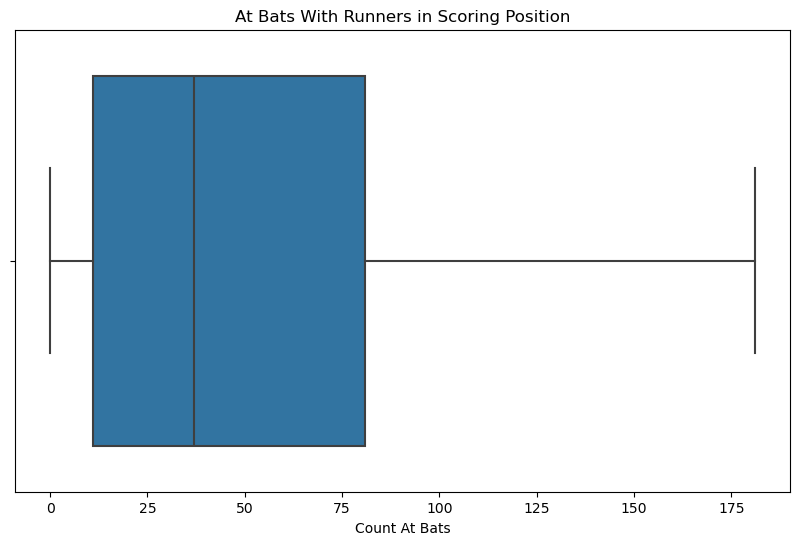

In [53]:
# Import packages 
import seaborn as sns
import numpy as np

# Build boxplot. 
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['abs'])
plt.title('At Bats With Runners in Scoring Position')
plt.xlabel('Count At Bats')

# Display
plt.show()

        Here we can see that any thing above 175 at bats is likely an outlier. Additionally we so not wish to evaluate performance from too small a sample size therefore lets go ahead and filter our dataset. 

In [59]:
# Filter Dataset by abs

# include only less than 175 abs. 
df = df[df['abs'] <= 175]

# include only greater than 5 abs. 

df = df[df['abs'] >= 5 ]

In [61]:
# Display shape to confirm that records have been removed form the dataset. 
df.shape


(2938, 36)

        Here we can confirm that we have removed some outliers in the data. 

# Evaluate Yearly Discrepancies in BA

Here we will see if there are any major difference in batting average year over year. Any major discrepencies may help inform our models built in later steps. 

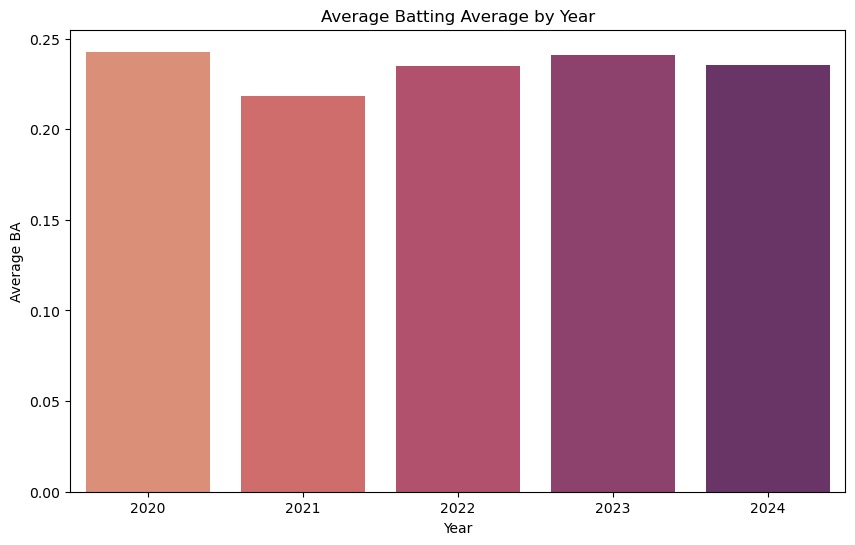

In [98]:
# Group by year to find average batting average. 
grouped_data = df.groupby('year')['ba'].mean().reset_index()

# Build the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='ba', data=grouped_data, palette='flare')

# Add titles and labels
plt.title('Average Batting Average by Year')
plt.xlabel('Year')
plt.ylabel('Average BA')

# Display the plot
plt.show()

    The graph above helps us show that we do not see any wild variations year over year. this means that as we build our models in futer steps we do not need to normalize data by year and we can evaluate all years as essentially equal. 

In [ ]:
# Building Correlation Matrix Run Expectancy. 

This correlation matrix will help us identiy as well as inform what metrics to put into a regression model moving forward. 

In [75]:
# Select columns to build corelation matrix off of. 
columns_of_interest = ['pitches','swings', 'takes', 'whiffs', 'ba', 'slg', 'run_exp']
correlation_data = df[columns_of_interest]

# Use corr to build to correlation matrix. 
correlation_matrix = correlation_data.corr()

correlation_matrix

,pitches,swings,takes,whiffs,ba,slg,run_exp
pitches,1.000000,0.983602,0.985061,0.884010,0.290145,0.332880,0.285739
swings,0.983602,1.000000,0.937851,0.911699,0.296747,0.332082,0.270604
takes,0.985061,0.937851,1.000000,0.830535,0.274973,0.323467,0.291463
whiffs,0.884010,0.911699,0.830535,1.000000,0.202970,0.292074,0.167357
ba,0.290145,0.296747,0.274973,0.202970,1.000000,0.823501,0.589456
slg,0.332880,0.332082,0.323467,0.292074,0.823501,1.000000,0.624230
run_exp,0.285739,0.270604,0.291463,0.167357,0.589456,0.624230,1.000000


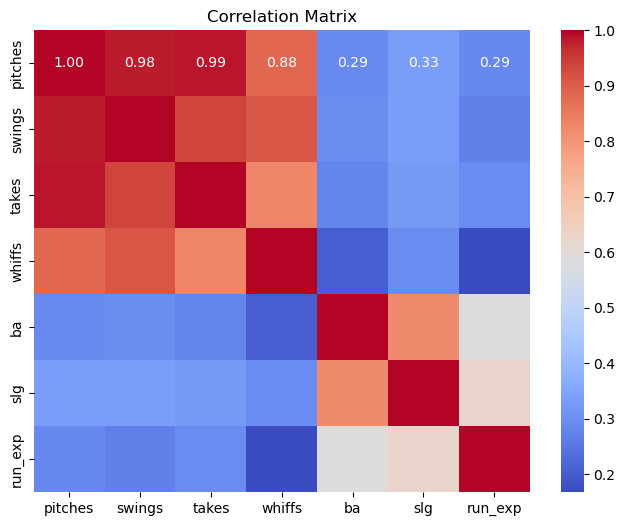

In [77]:
# Visualize the correlation matrix
# Use a heatmap. 
plt.figure(figsize=(8, 6))
# Use color coolwarm blue is highly inverse correlated red highly positively correlated. 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

        Above we can see the relationships between several of the variables available to us in the dateset. The relationship we are most concerned with here is the relationship the variables have with run expectancy as ultimately we are trying to find players who are successful an likely to drive in runs with runners in scoring position. In the next map we will further drill down that relationship. 

In [90]:
# Narrow down the correlation matrix to just run_exp relationships 

# Select the last row. 
run_exp_cor_matrix = correlation_matrix.tail(1)

# preview 
run_exp_cor_matrix

,pitches,swings,takes,whiffs,ba,slg,run_exp
run_exp,0.285739,0.270604,0.291463,0.167357,0.589456,0.62423,1.0


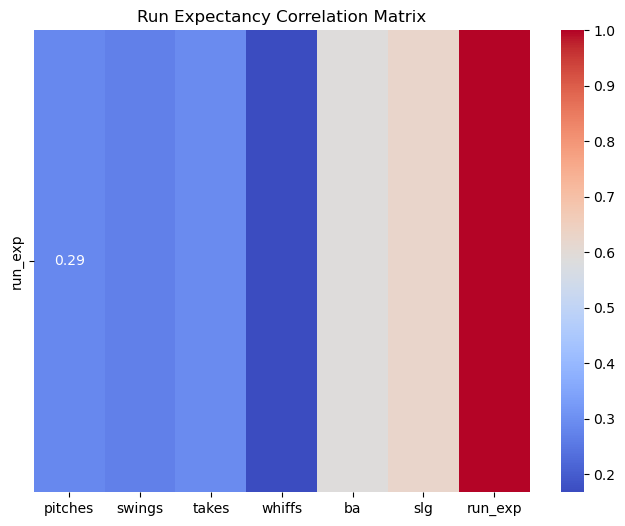

In [92]:
# Visualize the correlation matrix
# Use a heatmap. 
plt.figure(figsize=(8, 6))
# Use color coolwarm blue is highly inverse correlated red highly positively correlated. 
sns.heatmap(run_exp_cor_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Run Expectancy Correlation Matrix')
plt.show()


        As We can see above batting average and slugging are the tow variables most strongly related to run expectancy. Takes is the next most closely correlated variables. These relationships help give us some direction for when we build our regression model moving forward. We know that as batting average, slugging percentage and takes increase. run expectancy is also likely to increase. 

# Conclusion

        Moving Forward in this section of the project we have confirmed the common sentiment that the Minnesota Twins lack clutch hitting. This is seen in our first histogram where the Twins average with runners in scoring position falls far short of the average MLB player the past 5 seasons. Our box and Whisker plot has also allowed us to remove players that are outliers in terms of at bats. Players without enough plate appearances are likely bench players of minor leaguers. On the other hand, players with an extremely high level of appearances are an anomaly. Removing these outliers will allow us to analyze players more fairly.  We found that averages are relative across all of the years analyzed, meaning that we do not have to normalize any of the data to compensate for Major league baseball playing differently, for example the 2019 season with an experimental ball. Lastly, we identified via correlation matrix some player statistics that show strong positive relationships with run expectancy. These statistics will hopefully become strong predictors in our model as we seek to find players that can maximize run potential with runners in scoring position. All together the work done in this section of the project sets us up well moving forward and informs our model building in the next sections.  

# Final Project Milestone 2

# Discussion 

        Upon evaluation of Milestone 1 I have determined it is necessary to add some demographic information from players such as age, height and weight to better inform my models. Naturally historical hitting data is likely to be the most important data for model building however, adding this demographic information will add some dimension to both the model predicting future hitting success with runners in scoring position as well as the KNN clustering model to identify a group of similar players the Twins may wish to pursue in the off-season to address their clutch hitting issue. 

# Acquire Height and Weight Data

In this step we will read in data of current MLB players height, weight and age gathered by the University of Michigan's SOCR Department. 

In [135]:
# Use read_html to read in the list of tables in wiki page. 
wiki_list_dfs = pd.read_html("https://wiki.socr.umich.edu/index.php/SOCR_Data_MLB_HeightsWeights",
                    header=0)

In [136]:
# Check length of the list that is returned
# This is the number of tables in the webpage
len(wiki_list_dfs)

2

In [137]:
# Loop through each table in the wiki df.
# print the shape of each data frame.
# this will help us identify the proper table for out dataset.
for t in wiki_list_dfs:
    print("Table Shape: ", t.shape)

Table Shape:  (1034, 6)
Table Shape:  (1, 12)


The table we wish to read in is the first table we will access it using index 0.

In [146]:
# Select the first element, index 0
# Assign this table to new df and display. 
wiki = wiki_list_dfs[0]

# Visualize dataframe. 
wiki

,Name,Team,Position,Height(inches),Weight(pounds),Age
0,Adam_Donachie,BAL,Catcher,74,180,22.99
1,Paul_Bako,BAL,Catcher,74,215,34.69
2,Ramon_Hernandez,BAL,Catcher,72,210,30.78
3,Kevin_Millar,BAL,First_Baseman,72,210,35.43
4,Chris_Gomez,BAL,First_Baseman,73,188,35.71
...,...,...,...,...,...,...
1029,Brad_Thompson,STL,Relief_Pitcher,73,190,25.08
1030,Tyler_Johnson,STL,Relief_Pitcher,74,180,25.73
1031,Chris_Narveson,STL,Relief_Pitcher,75,205,25.19
1032,Randy_Keisler,STL,Relief_Pitcher,75,190,31.01


# Acquire Age Data

Now we wish to acquire age data for every player in our data set during that particular season. This information can be pulled from statcast. We will pull a report from every player who had an at bat 

In [161]:
# Packages
import pandas as pd

# Establish path to the HTML file
file_path = 'Statcast Search _ baseballsavant.com.html'

try:
    # Use pandas to read the HTML tables from the file
    tables = pd.read_html(file_path)

    # Display the number of tables found
    print(f"Number of tables found: {len(tables)}")
   
    # Loop through each table in the tables df.
    # print the shape of each data frame.
    # this will help us identify the proper table for out dataset.
    for t in wiki_list_dfs:
        print("Table Shape: ", t.shape)

except Exception as e:
    print("An error occurred while reading the HTML file.")
    print(e)


Number of tables found: 1
Table Shape:  (1034, 6)
Table Shape:  (1, 12)


The table that we want to use is the first table. Lets access it by using index 0. 



In [164]:
# Select the first element, index 0
# Assign this table to new df and display. 
age = tables[0]

# Visualize dataframe. 
age

,Rk.,Unnamed: 1,Player,Team,Result,Game Date,Vs.,Pitch (MPH),Batter Age (6/30),Unnamed: 9
0,1,NaN,"Suárez, Eugenio",SEA,Field Out,2023-07-19,MIN,104.8,31,Graphs
1,2,NaN,"Machado, Manny",SD,Strikeout,2024-08-07,PIT,104.7,31,Graphs
2,3,NaN,"Polanco, Jorge",SEA,Strikeout,2024-08-31,LAA,104.4,30,Graphs
3,4,NaN,"Schmitt, Casey",SF,Strikeout,2023-05-24,MIN,104.0,24,Graphs
4,5,NaN,"Ford, Mike",SEA,Strikeout,2023-07-19,MIN,104.0,30,Graphs
...,...,...,...,...,...,...,...,...,...,...
24995,24996,NaN,"Hernández, Teoscar",TOR,Double,2021-08-06,BOS,95.7,28,Graphs
24996,24997,NaN,"Marte, Ketel",AZ,Walk,2022-09-09,COL,95.7,28,Graphs
24997,24998,NaN,"Pages, Andy",LAD,Strikeout,2024-06-29,SF,95.7,23,Graphs
24998,24999,NaN,"Profar, Jurickson",SD,Field Out,2024-05-27,MIA,95.7,31,Graphs


# Drop any features that are not useful for your model building and explain why they are not useful.

First we will drop the age column from the Height and Weight dataset that was scraped from Wikipedia. We will drop this because that age is not date current as the last time that dataset was updated was two years ago. We have acquired season specific age information from statcast already. Additionally we will drop the team as it is not relevant to our analysis and player identification. 

In [151]:
# Drop age column from wiki dataset
wiki = wiki.drop(columns=['Age', 'Team'])

# Validate Column Drop. 
wiki

,Name,Position,Height(inches),Weight(pounds)
0,Adam_Donachie,Catcher,74,180
1,Paul_Bako,Catcher,74,215
2,Ramon_Hernandez,Catcher,72,210
3,Kevin_Millar,First_Baseman,72,210
4,Chris_Gomez,First_Baseman,73,188
...,...,...,...,...
1029,Brad_Thompson,Relief_Pitcher,73,190
1030,Tyler_Johnson,Relief_Pitcher,74,180
1031,Chris_Narveson,Relief_Pitcher,75,205
1032,Randy_Keisler,Relief_Pitcher,75,190


Remove all columns from the age dataframe except Player, Batter Age and Game Date. These features will be used later for either model building or data merging. 

In [169]:
# filter out unnecessary columns. 
age = age[['Player', 'Batter Age (6/30)', 'Game Date']]

# Visualize dataframe. 
age

,Player,Batter Age (6/30),Game Date
0,"Suárez, Eugenio",31,2023-07-19
1,"Machado, Manny",31,2024-08-07
2,"Polanco, Jorge",30,2024-08-31
3,"Schmitt, Casey",24,2023-05-24
4,"Ford, Mike",30,2023-07-19
...,...,...,...
24995,"Hernández, Teoscar",28,2021-08-06
24996,"Marte, Ketel",28,2022-09-09
24997,"Pages, Andy",23,2024-06-29
24998,"Profar, Jurickson",31,2024-05-27


Now we will evaluate the features that are currently stored in the Runners in Scoring Position dataframe and remove all features unnecessary for our analysis. 

In [172]:
df

,pitches,player_id,player_name,year,total_pitches,pitch_percent,ba,iso,babip,slg,...,pos4_int_start_distance,pos5_int_start_distance,pos6_int_start_distance,pos7_int_start_distance,pos8_int_start_distance,pos9_int_start_distance,pitcher_run_exp,run_exp,bat_speed,swing_length
21,48,676391,"Clement, Ernie",2023,155,31.0,0.667,0.133,0.667,0.800,...,146,113,144,297,317,280,-7.3,7.3,NaN,NaN
22,19,647351,"Toro, Abraham",2023,69,27.5,0.667,0.500,0.600,1.167,...,144,106,150,303,322,298,-4.6,4.6,NaN,NaN
29,83,650333,"Arraez, Luis",2020,512,16.2,0.579,0.263,0.579,0.842,...,140,102,139,281,312,300,-8.8,8.8,NaN,NaN
30,41,595943,"Evans, Phillip",2020,159,25.8,0.556,0.444,0.571,1.000,...,149,112,144,297,309,282,-5.7,5.7,NaN,NaN
31,48,663967,"Salazar, César",2024,111,43.2,0.500,0.100,0.455,0.600,...,139,104,144,286,321,289,-2.0,2.0,62.289433,6.945704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,39,622608,"Senzatela, Antonio",2021,159,24.5,0.000,0.000,0.000,0.000,...,133,97,138,292,302,272,5.9,-5.9,NaN,NaN
3371,39,621532,"Bemboom, Anthony",2022,244,16.0,0.000,0.000,0.000,0.000,...,152,103,148,290,317,290,1.9,-1.9,NaN,NaN
3375,23,594988,"Schebler, Scott",2021,114,20.2,0.000,0.000,0.000,0.000,...,160,118,153,290,318,292,2.3,-2.3,NaN,NaN
3380,32,670370,"Young, Andrew",2020,145,22.1,0.000,0.000,0.000,0.000,...,151,115,145,295,316,290,2.8,-2.8,NaN,NaN


In [174]:
# Print all column names 
print(df.columns.tolist())

['pitches', 'player_id', 'player_name', 'year', 'total_pitches', 'pitch_percent', 'ba', 'iso', 'babip', 'slg', 'woba', 'xwoba', 'xba', 'hits', 'abs', 'launch_speed', 'launch_angle', 'spin_rate', 'velocity', 'effective_speed', 'whiffs', 'swings', 'takes', 'eff_min_vel', 'release_extension', 'pos3_int_start_distance', 'pos4_int_start_distance', 'pos5_int_start_distance', 'pos6_int_start_distance', 'pos7_int_start_distance', 'pos8_int_start_distance', 'pos9_int_start_distance', 'pitcher_run_exp', 'run_exp', 'bat_speed', 'swing_length']


Here we see that our dataset includes data that is not batter specific but pitch data to the pitches that the player is facing. We wish to only evaluate the players on their own performance. For example a hitter has not control of the defensive positioning of their opponent and it would be unfair and ineffective to evaluate players using these features. Therefore we will remove all of the pitching metrics from the dataframe. Additionally we will remove the player ID as it is unnecessary to our project. 

In [181]:
# Filter Dataframe to only include batter information 

df = df[['pitches', 'player_name', 'year', 'total_pitches', 'pitch_percent', 'ba', 'iso', 'babip', 
         'slg', 'woba', 'xwoba', 'xba', 'hits', 'abs', 'launch_speed', 'launch_angle', 'whiffs', 'swings',
         'takes', 'run_exp', 'bat_speed', 'swing_length']]


In [183]:
# Preview df
df

,pitches,player_name,year,total_pitches,pitch_percent,ba,iso,babip,slg,woba,...,hits,abs,launch_speed,launch_angle,whiffs,swings,takes,run_exp,bat_speed,swing_length
21,48,"Clement, Ernie",2023,155,31.0,0.667,0.133,0.667,0.800,0.594,...,10.0,15.0,81.3,12.1,5,36,12,7.3,NaN,NaN
22,19,"Toro, Abraham",2023,69,27.5,0.667,0.500,0.600,1.167,0.775,...,4.0,6.0,89.2,13.5,4,10,9,4.6,NaN,NaN
29,83,"Arraez, Luis",2020,512,16.2,0.579,0.263,0.579,0.842,0.586,...,11.0,19.0,91.3,20.5,4,34,49,8.8,NaN,NaN
30,41,"Evans, Phillip",2020,159,25.8,0.556,0.444,0.571,1.000,0.663,...,5.0,9.0,86.6,8.5,7,19,22,5.7,NaN,NaN
31,48,"Salazar, César",2024,111,43.2,0.500,0.100,0.455,0.600,0.442,...,5.0,10.0,82.7,14.7,7,30,18,2.0,62.289433,6.945704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,39,"Senzatela, Antonio",2021,159,24.5,0.000,0.000,0.000,0.000,0.000,...,0.0,10.0,49.8,-6.0,6,26,13,-5.9,NaN,NaN
3371,39,"Bemboom, Anthony",2022,244,16.0,0.000,0.000,0.000,0.000,0.138,...,0.0,8.0,74.2,-4.0,3,13,26,-1.9,NaN,NaN
3375,23,"Schebler, Scott",2021,114,20.2,0.000,0.000,0.000,0.000,0.000,...,0.0,5.0,65.2,14.0,6,12,11,-2.3,NaN,NaN
3380,32,"Young, Andrew",2020,145,22.1,0.000,0.000,0.000,0.000,0.104,...,0.0,6.0,67.7,-19.3,6,13,19,-2.8,NaN,NaN


Here We can see that we have dropped any irrelevant features from the datasets. 

# Perform any data extraction/selection steps.

In the Age data set we need to extract the season year from each player. We do not need to keep the entire game date column. This feature extraction is essential because we need that information as part of our composite key to merge this dataframe with the savant data in future steps. 

In [207]:
# Extract year from game date in the age df. 

# Convert the date column in the age df to datetime format
age['Game Date'] = pd.to_datetime(age['Game Date'])

# Extract the year from the date column
age['year'] = age['Game Date'].dt.year

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_81273/1641284674.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age['Game Date'] = pd.to_datetime(age['Game Date'])
/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_81273/1641284674.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age['year'] = age['Game Date'].dt.year


In [209]:
# Validate
age

,Player,Batter Age (6/30),Game Date,year
0,"Suárez, Eugenio",31,2023-07-19,2023
1,"Machado, Manny",31,2024-08-07,2024
2,"Polanco, Jorge",30,2024-08-31,2024
3,"Schmitt, Casey",24,2023-05-24,2023
4,"Ford, Mike",30,2023-07-19,2023
...,...,...,...,...
24995,"Hernández, Teoscar",28,2021-08-06,2021
24996,"Marte, Ketel",28,2022-09-09,2022
24997,"Pages, Andy",23,2024-06-29,2024
24998,"Profar, Jurickson",31,2024-05-27,2024


In [211]:
# Drop the 'Game Date' column
age = age.drop('Game Date', axis=1)

# Validate
age

,Player,Batter Age (6/30),year
0,"Suárez, Eugenio",31,2023
1,"Machado, Manny",31,2024
2,"Polanco, Jorge",30,2024
3,"Schmitt, Casey",24,2023
4,"Ford, Mike",30,2023
...,...,...,...
24995,"Hernández, Teoscar",28,2021
24996,"Marte, Ketel",28,2022
24997,"Pages, Andy",23,2024
24998,"Profar, Jurickson",31,2024


# Remove Duplicates

Naturally now this dataframe (age) has many duplicates because it contains information from every game event with runners in scoring position since the 2020 MLB season. We now need to remove all the duplicate rows to make our data more concise and aid in merging moving forward. 

In [216]:
# Remove duplicates from age dataframe. 
age = age.drop_duplicates()


In [218]:
# Verify. 
age

,Player,Batter Age (6/30),year
0,"Suárez, Eugenio",31,2023
1,"Machado, Manny",31,2024
2,"Polanco, Jorge",30,2024
3,"Schmitt, Casey",24,2023
4,"Ford, Mike",30,2023
...,...,...,...
24675,"Maldonado, Martín",37,2024
24727,"Thompson, Zach",27,2021
24845,"Barrera, Luis",26,2022
24942,"Pinder, Chad",29,2021


Here we can see that we have removed all duplicates as our dataframe has gone from 250,000 rows to 2844.

# Transform features if necessary.

Here we will transform the player name in the demographic dataset (df named wiki) to match the two datasets we are using that were pulled directly from baseball savant. This will help us merge to one data set moving forward. 

In [195]:
# Reformat name column in wiki df 
# Change to Last, First 
# Use str split on the underscore and rearrange 
wiki['Name'] = wiki['Name'].str.split('_').apply(lambda x: f"{x[1]}, {x[0]}")

In [197]:
# Validate
wiki

,Name,Position,Height(inches),Weight(pounds)
0,"Donachie, Adam",Catcher,74,180
1,"Bako, Paul",Catcher,74,215
2,"Hernandez, Ramon",Catcher,72,210
3,"Millar, Kevin",First_Baseman,72,210
4,"Gomez, Chris",First_Baseman,73,188
...,...,...,...,...
1029,"Thompson, Brad",Relief_Pitcher,73,190
1030,"Johnson, Tyler",Relief_Pitcher,74,180
1031,"Narveson, Chris",Relief_Pitcher,75,205
1032,"Keisler, Randy",Relief_Pitcher,75,190


In [237]:
# Loop through and print the first 100 values in the 'Name' column
# Validate that the formating is correct 
for name in wiki['Name'].iloc[:20]:
    print(name)

Donachie, Adam
Bako, Paul
Hernandez, Ramon
Millar, Kevin
Gomez, Chris
Roberts, Brian
Tejada, Miguel
Mora, Melvin
Huff, Aubrey
Stern, Adam
Fiorentino, Jeff
Bynum, Freddie
Markakis, Nick
Fahey, Brandon
Patterson, Corey
Payton, Jay
Gibbons, Jay
Bedard, Erik
Penn, Hayden
Loewen, Adam


In [241]:
# Check to see if the name column has trailing spaces from wiki df. 

has_trailing_spaces = wiki['Name'].str.endswith(' ').any()

if has_trailing_spaces:
    print("There are trailing spaces in the 'Name' column.")
else:
    print("There are no trailing spaces in the 'Name' column.")

There are no trailing spaces in the 'Name' column.


In [245]:
# Check to see if player_name in the savant dataframe.

# Check for trailing spaces in the 'Name' column
has_trailing_spaces = df['player_name'].str.endswith(' ').any()

if has_trailing_spaces:
    print("There are trailing spaces in the 'player_name' column.")
else:
    print("There are no trailing spaces in the 'player_name' column.")

There are trailing spaces in the 'player_name' column.


Here we can see that we have trailing spaces in the player name column which means that we will be unable to use this as an effective key. We must remove the trailing spaces from the player name column in the savant data.

In [248]:
# Remove leading and trailing spaces in the player_name column from baseball savant. 
# Use strip. 
df['player_name'] = df['player_name'].str.strip()


/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_81273/3912849576.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['player_name'] = df['player_name'].str.strip()


In [250]:
# verify that the spaces were removed from the savant data.

# Check to see if player_name in the savant dataframe.

# Check for trailing spaces in the 'Name' column
has_trailing_spaces = df['player_name'].str.endswith(' ').any()

if has_trailing_spaces:
    print("There are trailing spaces in the 'player_name' column.")
else:
    print("There are no trailing spaces in the 'player_name' column.")

There are no trailing spaces in the 'player_name' column.


In [260]:
# Remove leading and trailing spaces in the 'Player' column from the age dataframe. 
# Use strip. 
age['Player'] = age['Player'].str.strip()

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_81273/326464355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age['Player'] = age['Player'].str.strip()


In [262]:
# Validate the removal of trailing spaces from the Player column 

# Check for trailing spaces in the 'Player' column
has_trailing_spaces = age['Player'].str.endswith(' ').any()

if has_trailing_spaces:
    print("There are trailing spaces in the 'Player' column.")
else:
    print("There are no trailing spaces in the 'Player' column.")

There are no trailing spaces in the 'Player' column.


Here we can see that we have sucessfully transformed the name feature in the demographic dataset so we can merge all datasets together. 

# Merge into one DataFrame

Here we will merge all three dataframes we are currently working with into one dataframe. This will allow us to build models from one dataframe in the future. 

In [252]:
# Perform a left Join between the savant data and demographic data(wiki) 
# Initialize risp df
risp = pd.DataFrame()

# Savant data is on the left 
# age on the right
# Composite key of Player and year. 
# Left merge without suffixes
risp = pd.merge(df, wiki, left_on='player_name', right_on='Name', how='left', suffixes=('', ''))

In [254]:
# View dataframe
risp.head(50)

,pitches,player_name,year,total_pitches,pitch_percent,ba,iso,babip,slg,woba,...,whiffs,swings,takes,run_exp,bat_speed,swing_length,Name,Position,Height(inches),Weight(pounds)
0,48,"Clement, Ernie",2023,155,31.0,0.667,0.133,0.667,0.800,0.594,...,5,36,12,7.3,NaN,NaN,NaN,NaN,NaN,NaN
1,19,"Toro, Abraham",2023,69,27.5,0.667,0.500,0.600,1.167,0.775,...,4,10,9,4.6,NaN,NaN,NaN,NaN,NaN,NaN
2,83,"Arraez, Luis",2020,512,16.2,0.579,0.263,0.579,0.842,0.586,...,4,34,49,8.8,NaN,NaN,NaN,NaN,NaN,NaN
3,41,"Evans, Phillip",2020,159,25.8,0.556,0.444,0.571,1.000,0.663,...,7,19,22,5.7,NaN,NaN,NaN,NaN,NaN,NaN
4,48,"Salazar, César",2024,111,43.2,0.500,0.100,0.455,0.600,0.442,...,7,30,18,2.0,62.289433,6.945704,NaN,NaN,NaN,NaN
5,73,"Greiner, Grayson",2021,344,21.2,0.500,0.250,0.700,0.750,0.558,...,8,29,44,4.0,NaN,NaN,NaN,NaN,NaN,NaN
6,36,"Brennan, Will",2022,150,24.0,0.500,0.300,0.500,0.800,0.572,...,6,25,11,4.1,NaN,NaN,NaN,NaN,NaN,NaN
7,76,"Stevenson, Andrew",2020,191,39.8,0.500,0.333,0.667,0.833,0.592,...,5,28,48,7.1,NaN,NaN,NaN,NaN,NaN,NaN
8,28,"Davis, Jonathan",2020,152,18.4,0.500,0.167,0.500,0.667,0.429,...,3,16,12,1.4,NaN,NaN,NaN,NaN,NaN,NaN
9,30,"Urías, Ramón",2020,108,27.8,0.500,0.167,0.500,0.667,0.550,...,0,10,20,1.7,NaN,NaN,NaN,NaN,NaN,NaN


In [264]:
# Drop Name Column 
risp = risp.drop('Name', axis=1)

In [266]:
# Perform a left Join between the risp dataframe and age dataframe. 
# Composite key 
# Left: player_name and year
# Right: Player and  year

risp = pd.merge(risp, age, left_on=['player_name', 'year'], right_on=['Player', 'year'], how='left')

In [273]:
# view. 
risp

,pitches,player_name,year,total_pitches,pitch_percent,ba,iso,babip,slg,woba,...,whiffs,swings,takes,run_exp,bat_speed,swing_length,Position,Height(inches),Weight(pounds),Batter Age (6/30)
0,48,"Clement, Ernie",2023,155,31.0,0.667,0.133,0.667,0.800,0.594,...,5,36,12,7.3,NaN,NaN,NaN,NaN,NaN,27.0
1,19,"Toro, Abraham",2023,69,27.5,0.667,0.500,0.600,1.167,0.775,...,4,10,9,4.6,NaN,NaN,NaN,NaN,NaN,NaN
2,83,"Arraez, Luis",2020,512,16.2,0.579,0.263,0.579,0.842,0.586,...,4,34,49,8.8,NaN,NaN,NaN,NaN,NaN,23.0
3,41,"Evans, Phillip",2020,159,25.8,0.556,0.444,0.571,1.000,0.663,...,7,19,22,5.7,NaN,NaN,NaN,NaN,NaN,NaN
4,48,"Salazar, César",2024,111,43.2,0.500,0.100,0.455,0.600,0.442,...,7,30,18,2.0,62.289433,6.945704,NaN,NaN,NaN,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,39,"Senzatela, Antonio",2021,159,24.5,0.000,0.000,0.000,0.000,0.000,...,6,26,13,-5.9,NaN,NaN,NaN,NaN,NaN,26.0
2936,39,"Bemboom, Anthony",2022,244,16.0,0.000,0.000,0.000,0.000,0.138,...,3,13,26,-1.9,NaN,NaN,NaN,NaN,NaN,NaN
2937,23,"Schebler, Scott",2021,114,20.2,0.000,0.000,0.000,0.000,0.000,...,6,12,11,-2.3,NaN,NaN,NaN,NaN,NaN,NaN
2938,32,"Young, Andrew",2020,145,22.1,0.000,0.000,0.000,0.000,0.104,...,6,13,19,-2.8,NaN,NaN,NaN,NaN,NaN,NaN


In [270]:
# Drop Player column. 
risp = risp.drop('Player', axis=1)

Here we have successfully merged three datasets containing information on age, height and weight as well as their hitting statistics with runners in scoring position.

# Engineer new useful features.

        Here we will engineer several useful features. swing percentage, take percentage and whiff percentage. These new features will help contextualize the counting stats and help us evaluate players based on their performance overall. otherwise we may be evaluating players more highly that are simply getting more opportunities with runners in scoring position. Additionally, we will add a pitches per at bat to help quantify the quality of at bats taken. 

In [275]:
# Print all column names in the risp DataFrame
print(risp.columns.tolist()) 

['pitches', 'player_name', 'year', 'total_pitches', 'pitch_percent', 'ba', 'iso', 'babip', 'slg', 'woba', 'xwoba', 'xba', 'hits', 'abs', 'launch_speed', 'launch_angle', 'whiffs', 'swings', 'takes', 'run_exp', 'bat_speed', 'swing_length', 'Position', 'Height(inches)', 'Weight(pounds)', 'Batter Age (6/30)']


In [277]:
# Engineer Whiff% 
# whiffs/swings

risp['whiff%'] = risp['whiffs']/risp['swings']

In [279]:
# Engineer swing% 
# swings/pitches

risp['swing%'] = risp['swings']/risp['pitches']

In [281]:
# Engineer takes% 
# takes/ pitches
risp['take%'] = risp['takes']/risp['pitches']

In [ ]:
# Drop total_pitches and pitch_percent 
# This is a pitching stat that was not removed earlier. 

risp = risp.drop('total_pitches', axis=1)

In [293]:
# Engineer pitches per at bat. 
# pitches/abs

risp['pitch/abs'] = risp['pitches']/risp['abs']

In [299]:
# Drop the counting stats of whiffs, swings, takes and pitches as we have represented this information in terms of a percent.  

risp = risp.drop(['whiffs', 'takes', 'swings', 'pitches'], axis=1)

In [303]:
# Preview df
risp


,player_name,year,ba,iso,babip,slg,woba,xwoba,xba,hits,...,bat_speed,swing_length,Position,Height(inches),Weight(pounds),Batter Age (6/30),whiff%,swing%,take%,pitch/abs
0,"Clement, Ernie",2023,0.667,0.133,0.667,0.800,0.594,0.386,0.430,10.0,...,NaN,NaN,NaN,NaN,NaN,27.0,0.138889,0.750000,0.250000,3.200000
1,"Toro, Abraham",2023,0.667,0.500,0.600,1.167,0.775,0.695,0.617,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.400000,0.526316,0.473684,3.166667
2,"Arraez, Luis",2020,0.579,0.263,0.579,0.842,0.586,0.490,0.393,11.0,...,NaN,NaN,NaN,NaN,NaN,23.0,0.117647,0.409639,0.590361,4.368421
3,"Evans, Phillip",2020,0.556,0.444,0.571,1.000,0.663,0.442,0.320,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.368421,0.463415,0.536585,4.555556
4,"Salazar, César",2024,0.500,0.100,0.455,0.600,0.442,0.387,0.404,5.0,...,62.289433,6.945704,NaN,NaN,NaN,28.0,0.233333,0.625000,0.375000,4.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,"Senzatela, Antonio",2021,0.000,0.000,0.000,0.000,0.000,0.123,0.117,0.0,...,NaN,NaN,NaN,NaN,NaN,26.0,0.230769,0.666667,0.333333,3.900000
2936,"Bemboom, Anthony",2022,0.000,0.000,0.000,0.000,0.138,0.395,0.270,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.230769,0.333333,0.666667,4.875000
2937,"Schebler, Scott",2021,0.000,0.000,0.000,0.000,0.000,0.054,0.060,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.521739,0.478261,4.600000
2938,"Young, Andrew",2020,0.000,0.000,0.000,0.000,0.104,0.155,0.058,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.461538,0.406250,0.593750,5.333333


# Deal with missing data (do not just drop rows or columns without justifying this).

Loop through every column and print the percentage of missing data for each column this will help us evaluate what to do with the missing data. 

In [309]:
# Find missing data percentages. 

# Loop through all columns in risp
for column in risp.columns:
    # Find misisng percentage
    missing_percentage = risp[column].isnull().mean() * 100  # Calculate percentage
    # print results. 
    print(f"Column '{column}': {missing_percentage:.2f}% missing values")

Column 'player_name': 0.00% missing values
Column 'year': 0.00% missing values
Column 'ba': 0.00% missing values
Column 'iso': 0.00% missing values
Column 'babip': 0.03% missing values
Column 'slg': 0.00% missing values
Column 'woba': 0.00% missing values
Column 'xwoba': 0.00% missing values
Column 'xba': 0.00% missing values
Column 'hits': 0.00% missing values
Column 'abs': 0.00% missing values
Column 'launch_speed': 0.00% missing values
Column 'launch_angle': 0.00% missing values
Column 'run_exp': 0.00% missing values
Column 'bat_speed': 80.17% missing values
Column 'swing_length': 80.17% missing values
Column 'Position': 98.95% missing values
Column 'Height(inches)': 98.95% missing values
Column 'Weight(pounds)': 98.95% missing values
Column 'Batter Age (6/30)': 6.94% missing values
Column 'whiff%': 0.00% missing values
Column 'swing%': 0.00% missing values
Column 'take%': 0.00% missing values
Column 'pitch/abs': 0.00% missing values


In [313]:
# Replace missing values from 'babip' with the column average. 
# batting average balls in play. 

# Calculate the average of the 'babip' column, ignoring NaN values
babip_average = risp['babip'].mean()

# Replace missing values in the 'babip' column with the average
risp['babip'] = risp['babip'].fillna(babip_average)

In [317]:
# Replace missing bat speed values with the median bat speed. 

# Calculate the average of the 'bat_speed' column, ignoring NaN values
batspeed_average = risp['bat_speed'].median()

# Replace missing values in the 'bat_speed' column with the average
risp['bat_speed'] = risp['bat_speed'].fillna(batspeed_average)

In [319]:
# Replace missing swing length values with the median bat speed. 

# Calculate the average of the 'swing_length' column, ignoring NaN values
swinglength_average = risp['swing_length'].median()

# Replace missing values in the 'bat_speed' column with the average
risp['swing_length'] = risp['swing_length'].fillna(swinglength_average)

In [323]:
# Replace Height and weight missing values with the average height and weight. 

# Calculate the average of the 'Height' column, ignoring NaN values
height_average = risp['Height(inches)'].mean()

# Replace missing values in the 'height' column with the average
risp['Height(inches)'] = risp['Height(inches)'].fillna(height_average)

# Calculate the average of the 'weight' column, ignoring NaN values
weight_average = risp['Weight(pounds)'].mean()

# Replace missing values in the 'weight' column with the average
risp['Weight(pounds)'] = risp['Weight(pounds)'].fillna(weight_average)

In [329]:
# Replace the Batter Age missing values with the median value for the group. 

# Calculate the median of the 'weight' column, ignoring NaN values
age_average = risp['Batter Age (6/30)'].median()

# Replace missing values in the 'weight' column with the average
risp['Batter Age (6/30)'] = risp['Batter Age (6/30)'].fillna(age_average)

In [333]:
# Validate the handling of all missing values. 

# Loop through all columns in risp
for column in risp.columns:
    # Find misisng percentage
    missing_percentage = risp[column].isnull().mean() * 100  # Calculate percentage
    # print results. 
    print(f"Column '{column}': {missing_percentage:.2f}% missing values")

Column 'player_name': 0.00% missing values
Column 'year': 0.00% missing values
Column 'ba': 0.00% missing values
Column 'iso': 0.00% missing values
Column 'babip': 0.00% missing values
Column 'slg': 0.00% missing values
Column 'woba': 0.00% missing values
Column 'xwoba': 0.00% missing values
Column 'xba': 0.00% missing values
Column 'hits': 0.00% missing values
Column 'abs': 0.00% missing values
Column 'launch_speed': 0.00% missing values
Column 'launch_angle': 0.00% missing values
Column 'run_exp': 0.00% missing values
Column 'bat_speed': 0.00% missing values
Column 'swing_length': 0.00% missing values
Column 'Position': 98.95% missing values
Column 'Height(inches)': 0.00% missing values
Column 'Weight(pounds)': 0.00% missing values
Column 'Batter Age (6/30)': 0.00% missing values
Column 'whiff%': 0.00% missing values
Column 'swing%': 0.00% missing values
Column 'take%': 0.00% missing values
Column 'pitch/abs': 0.00% missing values


        Here we can see that we have addressed all of the missing values except for the position column. We filled missing data in with he population mean for weight height and babip. We filled missing values with the mean here because in these circumstances the mean represents the population well. Age, swing length and speed were filled with the median as to not have some players who are very old or swing very hard change the representation of the missing values. 

# Create dummy variables if necessary.

        The only opportunity in our data set to create dummy variables would be in the position feature. However, This feature is missing over 98% of the data and building models using this feature would likely lead to serious overfitting as a model would be able to identify a particular player by simply calling the position feature. Additionally filling the missing data with the mode would likely lead to similar overfitting issues. Due to these circumstances the position feature will be dropped form the dataset and not considered in future model building. 

In [337]:
# Drop position feature

risp = risp.drop('Position', axis=1)

In [339]:
# View final dataset. 
risp

,player_name,year,ba,iso,babip,slg,woba,xwoba,xba,hits,...,run_exp,bat_speed,swing_length,Height(inches),Weight(pounds),Batter Age (6/30),whiff%,swing%,take%,pitch/abs
0,"Clement, Ernie",2023,0.667,0.133,0.667,0.800,0.594,0.386,0.430,10.0,...,7.3,68.376830,7.121569,74.0,201.129032,27.0,0.138889,0.750000,0.250000,3.200000
1,"Toro, Abraham",2023,0.667,0.500,0.600,1.167,0.775,0.695,0.617,4.0,...,4.6,68.376830,7.121569,74.0,201.129032,27.0,0.400000,0.526316,0.473684,3.166667
2,"Arraez, Luis",2020,0.579,0.263,0.579,0.842,0.586,0.490,0.393,11.0,...,8.8,68.376830,7.121569,74.0,201.129032,23.0,0.117647,0.409639,0.590361,4.368421
3,"Evans, Phillip",2020,0.556,0.444,0.571,1.000,0.663,0.442,0.320,5.0,...,5.7,68.376830,7.121569,74.0,201.129032,27.0,0.368421,0.463415,0.536585,4.555556
4,"Salazar, César",2024,0.500,0.100,0.455,0.600,0.442,0.387,0.404,5.0,...,2.0,62.289433,6.945704,74.0,201.129032,28.0,0.233333,0.625000,0.375000,4.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,"Senzatela, Antonio",2021,0.000,0.000,0.000,0.000,0.000,0.123,0.117,0.0,...,-5.9,68.376830,7.121569,74.0,201.129032,26.0,0.230769,0.666667,0.333333,3.900000
2936,"Bemboom, Anthony",2022,0.000,0.000,0.000,0.000,0.138,0.395,0.270,0.0,...,-1.9,68.376830,7.121569,74.0,201.129032,27.0,0.230769,0.333333,0.666667,4.875000
2937,"Schebler, Scott",2021,0.000,0.000,0.000,0.000,0.000,0.054,0.060,0.0,...,-2.3,68.376830,7.121569,74.0,201.129032,27.0,0.500000,0.521739,0.478261,4.600000
2938,"Young, Andrew",2020,0.000,0.000,0.000,0.000,0.104,0.155,0.058,0.0,...,-2.8,68.376830,7.121569,74.0,201.129032,27.0,0.461538,0.406250,0.593750,5.333333


In [341]:
# Write to CSV 

risp.to_csv('risp_data_prepped.csv', index=False)

# Final Project Milestone 3

## Build Regression Model to Predict Future Hitting Success with Runners in Scoring Position 

In [48]:
# Load risp DataFrame. 
# Import packages
import pandas as pd

# File path 
file_path = 'risp_data_prepped.csv'

# Read the .csv file into a DataFrame
# Note you can use read_csv just need to change the separator to '/t'
risp = pd.read_csv(file_path)


In [50]:
# Count the occurrences of each player name
name_counts = risp['player_name'].value_counts()

# Loop through the counts and print repeated names
print("Repeated player names and their counts:")
for name, count in name_counts.items():
    if count > 1:  # Check if the count is greater than 1
        print(f"{name}: {count}")

Repeated player names and their counts:
Rengifo, Luis: 5
Nimmo, Brandon: 5
Mullins, Cedric: 5
Tellez, Rowdy: 5
Urías, Luis: 5
Profar, Jurickson: 5
Newman, Kevin: 5
Swanson, Dansby: 5
Olson, Matt: 5
Semien, Marcus: 5
Rosario, Amed: 5
Hernández, Teoscar: 5
Carpenter, Matt: 5
Vargas, Ildemaro: 5
Springer, George: 5
Grichuk, Randal: 5
Edman, Tommy: 5
Biggio, Cavan: 5
Duvall, Adam: 5
Merrifield, Whit: 5
Casali, Curt: 5
Thomas, Lane: 5
Reynolds, Bryan: 5
Taylor, Michael A.: 5
Schwarber, Kyle: 5
Taylor, Tyrone: 5
Bregman, Alex: 5
Báez, Javier: 5
Senzel, Nick: 5
Riley, Austin: 5
Stanton, Giancarlo: 5
Wendle, Joey: 5
García Jr., Luis: 5
Acuña Jr., Ronald: 5
Jeffers, Ryan: 5
Guerrero Jr., Vladimir: 5
Canha, Mark: 5
Lopez, Nicky: 5
Ohtani, Shohei: 5
Contreras, Willson: 5
Kiermaier, Kevin: 5
d'Arnaud, Travis: 5
Dubón, Mauricio: 5
Berti, Jon: 5
Andujar, Miguel: 5
Yastrzemski, Mike: 5
Hays, Austin: 5
Martinez, J.D.: 5
Blackmon, Charlie: 5
McNeil, Jeff: 5
Perez, Salvador: 5
Slater, Austin: 5
Urshela,

In [52]:
# Find the number of players with multiple years of data. 

name_counts.shape

(1072,)

        Here We have validated that we have over 1000 records of player performances across multiple seasons. Seeing as the intention of the project is to be able to identify players that will perform well with Runners in Scoring Position in the future we will build our regression model to use previous years statistics to predict the next seasons woba (weighted on base average). We have chosen to predict woba because this statistic properly weights how a player got on base and takes into consideration the differences in run expectancy for each way of reaching base. We chose to predict this statistic instead of run expectancy because run expectancy is a cumulative statistic. This means that player with more opportunities with runners in scoring position are likely to accumulate more expected runs. 

In [55]:
# Loop through the data frame and add next_year_woba to all players when possible. 

# Loop through every row in risp 
for index, row in risp.iterrows():
    # Establish player and current year in search. 
    current_player = row['player_name']
    current_year = row['year']
    
    # Check for the next year's woba for the same player
    next_year = current_year + 1
    next_year_woba = risp[(risp['player_name'] == current_player) & (risp['year'] == next_year)]['woba']
    
    # If a value exists, add it to the new column
    if not next_year_woba.empty:
        risp.at[index, 'next_year_woba'] = next_year_woba.values[0]

# Display new risp 
risp

,player_name,year,ba,iso,babip,slg,woba,xwoba,xba,hits,...,bat_speed,swing_length,Height(inches),Weight(pounds),Batter Age (6/30),whiff%,swing%,take%,pitch/abs,next_year_woba
0,"Clement, Ernie",2023,0.667,0.133,0.667,0.800,0.594,0.386,0.430,10.0,...,68.376830,7.121569,74.0,201.129032,27.0,0.138889,0.750000,0.250000,3.200000,0.324
1,"Toro, Abraham",2023,0.667,0.500,0.600,1.167,0.775,0.695,0.617,4.0,...,68.376830,7.121569,74.0,201.129032,27.0,0.400000,0.526316,0.473684,3.166667,0.284
2,"Arraez, Luis",2020,0.579,0.263,0.579,0.842,0.586,0.490,0.393,11.0,...,68.376830,7.121569,74.0,201.129032,23.0,0.117647,0.409639,0.590361,4.368421,0.305
3,"Evans, Phillip",2020,0.556,0.444,0.571,1.000,0.663,0.442,0.320,5.0,...,68.376830,7.121569,74.0,201.129032,27.0,0.368421,0.463415,0.536585,4.555556,0.246
4,"Salazar, César",2024,0.500,0.100,0.455,0.600,0.442,0.387,0.404,5.0,...,62.289433,6.945704,74.0,201.129032,28.0,0.233333,0.625000,0.375000,4.800000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,"Senzatela, Antonio",2021,0.000,0.000,0.000,0.000,0.000,0.123,0.117,0.0,...,68.376830,7.121569,74.0,201.129032,26.0,0.230769,0.666667,0.333333,3.900000,NaN
2936,"Bemboom, Anthony",2022,0.000,0.000,0.000,0.000,0.138,0.395,0.270,0.0,...,68.376830,7.121569,74.0,201.129032,27.0,0.230769,0.333333,0.666667,4.875000,NaN
2937,"Schebler, Scott",2021,0.000,0.000,0.000,0.000,0.000,0.054,0.060,0.0,...,68.376830,7.121569,74.0,201.129032,27.0,0.500000,0.521739,0.478261,4.600000,NaN
2938,"Young, Andrew",2020,0.000,0.000,0.000,0.000,0.104,0.155,0.058,0.0,...,68.376830,7.121569,74.0,201.129032,27.0,0.461538,0.406250,0.593750,5.333333,0.337


We will now filter the data frame to only include values where we have a next_year_woba. Otherwise we cannot build a regression model. Additionally we do not want to fill the missing values because we do not want tom make assumptions of future player performance. 

In [58]:
# Use dropna to remove all rows with missing values from risp. 
risp = risp.dropna(subset=['next_year_woba'])

In [60]:
# Validate size of new df. 
risp.shape

(1812, 24)

Here we see that we still have over 1800 records to train our regression models moving forward. We will build a backwards stepwise regression to predict next seasons woba. This method will give us important statistically significant features MLB teams can use to identify clutch hitting players to acquire either in free agency or via trade. 

# Build Backward Stepwise Regression 
## P-value Threshold = 0.05

In [89]:
# Create a train test split. 

# Import packages. 
import pandas as pd
from sklearn.model_selection import train_test_split

# create features
features = risp.drop(columns=['player_name', 'next_year_woba'])
target = risp['next_year_woba']

# Split into 80 % training 20% test
# use train_test_split

features_train, features_test, target_train, target_test= train_test_split(features, target, test_size=0.2, random_state=42)

In [91]:
# Build stepwise regression with a p value threshold of 0.05

# Load Libraries
import pandas as pd
import statsmodels.api as sm

# Add a constant to the model (intercept)
features_train = sm.add_constant(features_train)

# Fit the initial model
model = sm.OLS(target_train, features_train).fit()

# Backward stepwise regression
while True:
    # Get the p-values of the model
    p_values = model.pvalues
    # Find the maximum p-value
    max_p_value = p_values.max()
    
    # If the maximum p-value is greater than 0.05, remove that variable
    if max_p_value > 0.05:
        # Identify the variable to remove
        variable_to_remove = p_values.idxmax()
        # Remove the variable from the model
        features_train = features_train.drop(variable_to_remove, axis=1)
        # Remove from test data as well 
        features_test = features_test.drop(variable_to_remove, axis=1)
        # Refit the model
        model = sm.OLS(target_train, features_train).fit()
    else:
        break

# Print the summary of the final model
print("Final model summary:")
print(model.summary())

# Prepare the test set for prediction
# Add constant to test set
features_test_final = features_test.copy()
features_test_final = sm.add_constant(features_test) 







Final model summary:
                            OLS Regression Results                            
Dep. Variable:         next_year_woba   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     18.00
Date:                Sat, 02 Nov 2024   Prob (F-statistic):           7.78e-26
Time:                        23:27:52   Log-Likelihood:                 1688.3
No. Observations:                1449   AIC:                            -3359.
Df Residuals:                    1440   BIC:                            -3311.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
year             

In [93]:
# Evaluate Fit 

# Load Libraries 
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Predictions
train_predictions = model.predict(features_train)
test_predictions = model.predict(features_test)

# R² Calculation
r2_train = r2_score(target_train, train_predictions)
r2_test = r2_score(target_test, test_predictions)

# RMSE Calculation
rmse_train = np.sqrt(mean_squared_error(target_train, train_predictions))
rmse_test = np.sqrt(mean_squared_error(target_test, test_predictions))

# Output the results
print(" P-Value Threshold 0.05")
print(f"Training R²: {r2_train}, Training RMSE: {rmse_train}")
print(f"Test R²: {r2_test}, Test RMSE: {rmse_test}")

 P-Value Threshold 0.05
Training R²: 0.09090149563938721, Training RMSE: 0.07546667132526712
Test R²: 0.08655594343469553, Test RMSE: 0.08076472812989989


# Build Backward Stepwise Regression 
## P-value Threshold = 0.3

In [96]:
# Build stepwise regression with a p value threshold of 0.3

# Create a train test split. 

# Import packages. 
import pandas as pd
from sklearn.model_selection import train_test_split

# create features
features = risp.drop(columns=['player_name', 'next_year_woba'])
target = risp['next_year_woba']

# Split into 80 % training 20% test
# use train_test_split

features_train, features_test, target_train, target_test= train_test_split(features, target, test_size=0.2, random_state=42)

# Load Libraries
import pandas as pd
import statsmodels.api as sm

# Add a constant to the model (intercept)
features_train = sm.add_constant(features_train)

# Fit the initial model
model = sm.OLS(target_train, features_train).fit()

# Backward stepwise regression
while True:
    # Get the p-values of the model
    p_values = model.pvalues
    # Find the maximum p-value
    max_p_value = p_values.max()
    
    # If the maximum p-value is greater than 0.3, remove that variable
    if max_p_value > 0.3:
        # Identify the variable to remove
        variable_to_remove = p_values.idxmax()
        # Remove the variable from the model
        features_train = features_train.drop(variable_to_remove, axis=1)
        # Remove from test data as well 
        features_test = features_test.drop(variable_to_remove, axis=1)
        # Refit the model
        model = sm.OLS(target_train, features_train).fit()
    else:
        break

# Print the summary of the final model
print("Final model summary:")
print(model.summary())

# Prepare the test set for prediction
# Add constant to test set
features_test_final = features_test.copy()
features_test_final = sm.add_constant(features_test) 

Final model summary:
                            OLS Regression Results                            
Dep. Variable:         next_year_woba   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     16.23
Date:                Sat, 02 Nov 2024   Prob (F-statistic):           1.33e-25
Time:                        23:27:59   Log-Likelihood:                 1689.3
No. Observations:                1449   AIC:                            -3359.
Df Residuals:                    1439   BIC:                            -3306.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
year             

In [98]:
# Evaluate Fit 

# Load Libraries 
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Predictions
train_predictions = model.predict(features_train)
test_predictions = model.predict(features_test)

# R² Calculation
r2_train = r2_score(target_train, train_predictions)
r2_test = r2_score(target_test, test_predictions)

# RMSE Calculation
rmse_train = np.sqrt(mean_squared_error(target_train, train_predictions))
rmse_test = np.sqrt(mean_squared_error(target_test, test_predictions))

# Output the results
print(" P-Value Threshold 0.3")
print(f"Training R²: {r2_train}, Training RMSE: {rmse_train}")
print(f"Test R²: {r2_test}, Test RMSE: {rmse_test}")

 P-Value Threshold 0.05
Training R²: 0.09215802308463716, Training RMSE: 0.07541449945814149
Test R²: 0.08249643627985748, Test RMSE: 0.08094399555412293


# Build a Linear Model Using Recursively Eliminating Features.

Here we will build a liner regression model where we recursively eliminate features using cross validation to repeatedly train the model removing features until model performance decreases leaving the remaining features as the best predictors of next season woba. 

In [101]:
# Build a Linear Model Using Recursively Eliminating Features.

# Create a train test split. 

# Import packages. 
import pandas as pd
from sklearn.model_selection import train_test_split

# create features
features = risp.drop(columns=['player_name', 'next_year_woba'])
target = risp['next_year_woba']

# Split into 80 % training 20% test
# use train_test_split

features_train, features_test, target_train, target_test= train_test_split(features, target, test_size=0.2, random_state=42)


In [117]:
# Load libraries
from sklearn.feature_selection import RFECV
from sklearn import linear_model

# create linear regression 
ols = linear_model.LinearRegression()

# Recursively Eliminate Features 
rfecv = RFECV(estimator=ols, step=1, cv =5, scoring="neg_mean_squared_error")
rfecv.fit(features_train, target_train)
rfecv.transform(features_train)

array([[2.02000000e+03, 1.89000000e-01, 1.90000000e-02, ...,
        5.22088353e-01, 4.77911647e-01, 4.69811321e+00],
       [2.02200000e+03, 2.32000000e-01, 1.43000000e-01, ...,
        4.25675676e-01, 5.74324324e-01, 5.28571429e+00],
       [2.02000000e+03, 8.30000000e-02, 0.00000000e+00, ...,
        6.17021277e-01, 3.82978723e-01, 3.91666667e+00],
       ...,
       [2.02200000e+03, 2.56000000e-01, 2.40000000e-01, ...,
        5.47758285e-01, 4.52241715e-01, 4.10400000e+00],
       [2.02100000e+03, 1.89000000e-01, 1.08000000e-01, ...,
        5.33333333e-01, 4.66666667e-01, 4.05405405e+00],
       [2.02200000e+03, 2.28000000e-01, 7.90000000e-02, ...,
        5.29816514e-01, 4.70183486e-01, 3.82456140e+00]])

In [123]:
# number of best features 
rfecv.n_features_

21

Here we see the the RFECV model has identified 21 different features to predict next season woba. 

In [125]:
# Get the selected features
selected_features = features_train.columns[rfecv.support_]

# Output the selected features
print("Selected Features:", selected_features.tolist())

Selected Features: ['year', 'ba', 'iso', 'babip', 'slg', 'woba', 'xwoba', 'xba', 'hits', 'abs', 'launch_speed', 'run_exp', 'bat_speed', 'swing_length', 'Height(inches)', 'Weight(pounds)', 'Batter Age (6/30)', 'whiff%', 'swing%', 'take%', 'pitch/abs']


In [137]:

# Get coefficients 
coefficients = rfecv.estimator_.coef_

# Print coefficients and feature names in a readable format
print("Coefficients and corresponding feature names:")
for feature, coef in zip(selected_features, coefficients):
    print(f"{feature}: {coef:.4f}")

# Get the intercept of the model
intercept = rfecv.estimator_.intercept_
print("Model intercept: ", intercept)

Coefficients and corresponding feature names:
year: -0.0072
ba: 0.0687
iso: -0.0122
babip: -0.1068
slg: 0.0228
woba: -0.0308
xwoba: 0.1031
xba: -0.0414
hits: -0.0005
abs: 0.0004
launch_speed: 0.0017
run_exp: 0.0010
bat_speed: -2275427.7007
swing_length: -142246.1157
Height(inches): 0.0181
Weight(pounds): 0.0023
Batter Age (6/30): -0.0022
whiff%: 0.0113
swing%: 4.4474
take%: 4.5004
pitch/abs: 0.0025
Model intercept:  156599557.91301754


In [139]:
# Evaluate Fit 

# Load Libraries 
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Predictions
train_predictions = rfecv.predict(features_train)
test_predictions = rfecv.predict(features_test)

# R² Calculation
r2_train = r2_score(target_train, train_predictions)
r2_test = r2_score(target_test, test_predictions)

# RMSE Calculation
rmse_train = np.sqrt(mean_squared_error(target_train, train_predictions))
rmse_test = np.sqrt(mean_squared_error(target_test, test_predictions))

# Output the results
print("Recursive Feature Elimination")
print(f"Training R²: {r2_train}, Training RMSE: {rmse_train}")
print(f"Test R²: {r2_test}, Test RMSE: {rmse_test}")

Recursive Feature Elimination
Training R²: 0.09417588321955317, Training RMSE: 0.07533064093960512
Test R²: 0.0877166549419458, Test RMSE: 0.08071339803046232


## Discussion

        When evaluating all of the linear models we have chosen to look at R^2 to evaluate how well the the model explains the variation that we see in the target variable next season woba. The first stepwise model where the p-value threshold is 0.05 is actually very competitive with the other two models and shows the least amount of overfitting as the test R^2 in this model performs most similarly to the training data. When evaluating the RMSE statistic across the three models all models performed similarly with little signs of overfitting. The importance of this statistic is it allows us to evaluate the error in our predictions while giving proper weight to large errors. Minimizing error in our predictions is relevant to our problem as we want to ensure the model we chose to implement does not have huge erroe margins. Imaging signing a free agent for millions of dollars and they do not meet their performance expectations from the regression model. This phenomena is why minimizing RMSE is important to our model selection. All this considered I would select the stepwise regression model with a p value threshold of 0.05 to implement in player selection because it shows the least signs of overfitting, is competitive with all other models in terms of error and is also the simplest model to understand and implement. 


# Fitting Clustering Models 
## Build K Means Clustering Model

In [221]:
# Create a train test split. 

# Import packages. 
import pandas as pd
from sklearn.model_selection import train_test_split

# create features
# Do not include next year woba in training of model. 
# The effectiveness of model assumes that we do not know that information yet.
features = risp.drop(columns=['player_name', 'next_year_woba'])
target = risp['next_year_woba']

# Split into 80 % training 20% test
# use train_test_split

features_train, features_test, target_train, target_test= train_test_split(features, target, test_size=0.2, random_state=42)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

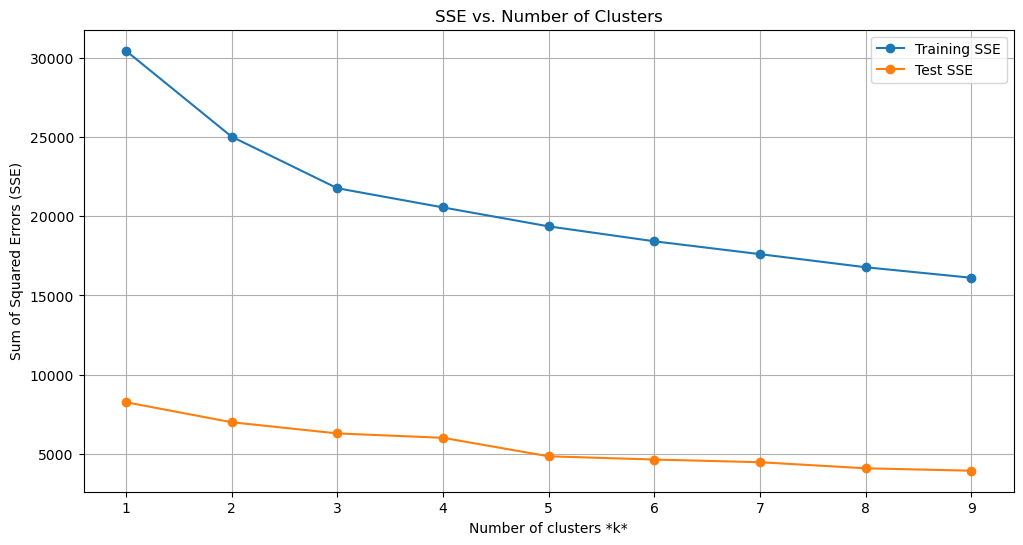

In [223]:
# Load Libraries 

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt


# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(features_train)
X_test_scaled = scaler.transform(features_test)

# Run the Kmeans algorithm and get the index of data points clusters
# initialize sum squared distance and lits of k to try 
sse = []
ssetest = []
list_k = list(range(1, 10))

for k in list_k:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_train_scaled)
    sse.append(kmeans.inertia_)
   
    # Predict cluster labels for the test data
    test_labels = kmeans.predict(X_test_scaled)
    
    # Calculate SSE for the test data
    test_sse = 0
    for i in range(len(X_test_scaled)):
        # Find the center of the cluster for the predicted label
        center = kmeans.cluster_centers_[test_labels[i]]
        # Calculate the squared distance from the test point to the cluster center
        test_sse += np.sum((X_test_scaled[i] - center) ** 2)
     # Append the SSE for test data   
    ssetest.append(test_sse)  

# Plot SSE against k
plt.figure(figsize=(12, 6))
plt.plot(list_k, sse, '-o', label='Training SSE')
plt.plot(list_k, ssetest, '-o', label='Test SSE')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('SSE vs. Number of Clusters')
plt.legend()
plt.grid(True)
plt.show()







        Looking at the elbow analysis above it looks like we should select to build a clustering model with K = 3. We see that as the number of clusters increases past three the return on decreasing sum squared errors also decreases. Meaning that we are not forming mors distinct groups but simply just more groups. To minimize overfitting we will move forward with k = 3. 

In [226]:
# Fit the K-Means model to the training data
n_clusters = 3  # Specify the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_train_scaled)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_6179/69185085.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risp['cluster'] = np.nan  # Initialize with NaN


<Figure size 1200x600 with 0 Axes>

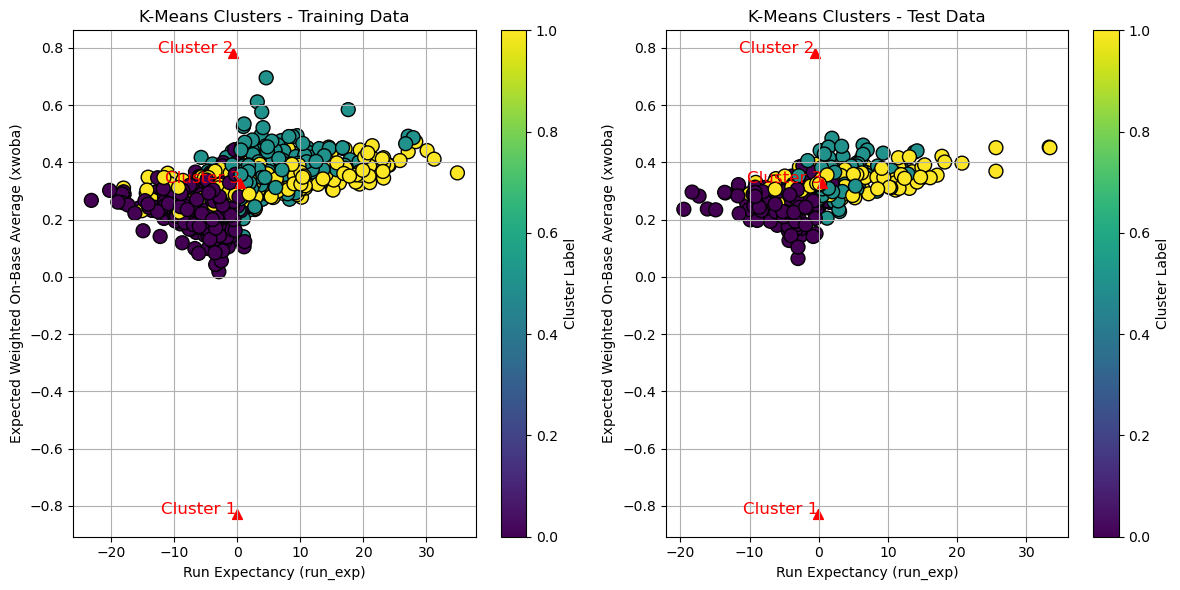

In [247]:
# Predict cluster labels for the training and test data
train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test_scaled)

# Visualize the clusters for the training data
plt.figure(figsize=(12, 6))

# Add cluster labels to the original DataFrame for visualization
risp['cluster'] = np.nan  # Initialize with NaN
risp.loc[features_train.index, 'cluster'] = train_labels  # Assign training labels
risp.loc[features_test.index, 'cluster'] = test_labels  # Assign test labels

# Visualize the clusters
plt.figure(figsize=(12, 6))

# Scatter plot for training data
plt.subplot(1, 2, 1)
# X axis run exp , y axis woba
plt.scatter(features_train['run_exp'], features_train['xwoba'], c=train_labels, cmap='viridis', marker='o', edgecolor='k', s=100)
# Plot cluster centers 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='^', s=50, label='Cluster Centers')
# Label each cluster center
# Loop through each cluster center
for i, center in enumerate(kmeans.cluster_centers_):
    plt.text(center[0], center[1], f'Cluster {i+1}', fontsize=12, ha='right', color='red')
plt.title('K-Means Clusters - Training Data')
plt.xlabel('Run Expectancy (run_exp)')
plt.ylabel('Expected Weighted On-Base Average (xwoba)')
plt.colorbar(label='Cluster Label')
plt.grid(True)

# Scatter plot for test data
plt.subplot(1, 2, 2)
plt.scatter(features_test['run_exp'], features_test['xwoba'], c=test_labels, cmap='viridis', marker='o', edgecolor='k', s=100)
# plot cluster center
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='^', s=50, label='Cluster Centers')
# Label each cluster center
for i, center in enumerate(kmeans.cluster_centers_):
    plt.text(center[0], center[1], f'Cluster {i+1}', fontsize=12, ha='right', color='red')
plt.title('K-Means Clusters - Test Data')
plt.xlabel('Run Expectancy (run_exp)')
plt.ylabel('Expected Weighted On-Base Average (xwoba)')
plt.colorbar(label='Cluster Label')
plt.grid(True)

plt.tight_layout()
# Display
plt.show()

## Discussion

        The goal of this clustering model is to help give the user a place to start when it comes to player evaluation. In other words we are looking to identify players that may be worth evaluating further to help improve performance with runners in scoring position. As we look at the first two cluster charts we see that the cluster with the highest xwoba is Cluster 2 (xwoba having already been shown a statistically significant predictor of next season woba. Based on this information I would begin player evaluations with those classified into cluster 2. 

# Build Classification Model to Classify Clutch Hitting.

        The purpose of this model is to provide MLB front offices with a simple classifier, yes or no decision, is this player a clutch hitter. The MLB standard for great woba is 0.370. This model will classify if a player is a great clutch hitter. The utility of this model is that many time MLB trades happen fast and quickly before the deadline, this model will allow management to simply look a players classification and immediately be able to make a decision if that player will fill the clutch row or not while on the phone with other teams. 

In [267]:
# Create binary predictor for next year clutch hitting. 
# Use greater than or equal to 0.370 as the threshold
# Create a dummy variable based on the condition
risp['next_year_clutch'] = (risp['next_year_woba'] >= 0.370).astype(int)

# Preview
risp.head(10)

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_6179/3130535329.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risp['next_year_clutch'] = (risp['next_year_woba'] >= 0.370).astype(int)


,player_name,year,ba,iso,babip,slg,woba,xwoba,xba,hits,...,Height(inches),Weight(pounds),Batter Age (6/30),whiff%,swing%,take%,pitch/abs,next_year_woba,cluster,next_year_clutch
0,"Clement, Ernie",2023,0.667,0.133,0.667,0.800,0.594,0.386,0.430,10.0,...,74.0,201.129032,27.0,0.138889,0.750000,0.250000,3.200000,0.324,1.0,0
1,"Toro, Abraham",2023,0.667,0.500,0.600,1.167,0.775,0.695,0.617,4.0,...,74.0,201.129032,27.0,0.400000,0.526316,0.473684,3.166667,0.284,1.0,0
2,"Arraez, Luis",2020,0.579,0.263,0.579,0.842,0.586,0.490,0.393,11.0,...,74.0,201.129032,23.0,0.117647,0.409639,0.590361,4.368421,0.305,1.0,0
3,"Evans, Phillip",2020,0.556,0.444,0.571,1.000,0.663,0.442,0.320,5.0,...,74.0,201.129032,27.0,0.368421,0.463415,0.536585,4.555556,0.246,1.0,0
6,"Brennan, Will",2022,0.500,0.300,0.500,0.800,0.572,0.521,0.433,5.0,...,74.0,201.129032,27.0,0.240000,0.694444,0.305556,3.600000,0.261,1.0,0
7,"Stevenson, Andrew",2020,0.500,0.333,0.667,0.833,0.592,0.406,0.305,6.0,...,74.0,201.129032,26.0,0.178571,0.368421,0.631579,6.333333,0.289,1.0,0
8,"Davis, Jonathan",2020,0.500,0.167,0.500,0.667,0.429,0.337,0.259,3.0,...,74.0,201.129032,28.0,0.187500,0.571429,0.428571,4.666667,0.207,1.0,0
9,"Urías, Ramón",2020,0.500,0.167,0.500,0.667,0.550,0.393,0.289,3.0,...,74.0,201.129032,26.0,0.000000,0.333333,0.666667,5.000000,0.395,1.0,1
11,"Aquino, Aristides",2020,0.500,0.400,0.444,0.900,0.610,0.576,0.464,5.0,...,74.0,201.129032,27.0,0.263158,0.475000,0.525000,4.000000,0.279,1.0,0
14,"Grissom, Vaughn",2023,0.471,0.176,0.571,0.647,0.463,0.356,0.331,8.0,...,74.0,201.129032,22.0,0.222222,0.540000,0.460000,2.941176,0.175,1.0,0


In [295]:
# Create a train test split. 

# Import packages. 
import pandas as pd
from sklearn.model_selection import train_test_split

# create features
# Do not include next year woba in training of model. 
# Do not includ next_year_clutch in the training model 
# The effectiveness of model assumes that we do not know that information yet.
# remove cluster from previous steps 
features = risp.drop(columns=['player_name', 'next_year_woba', 'next_year_clutch','cluster'])
target = risp['next_year_clutch']

# Split into 80 % training 20% test
# use train_test_split

features_train, features_test, target_train, target_test= train_test_split(features, target, test_size=0.2, random_state=42)


In [297]:
# Load libraries
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Initialize the Min-Max scaler
mmscaler = MinMaxScaler()

# define pipeline 
pipe = Pipeline([("MinMaxScaler", mmscaler), ("classifier", RandomForestClassifier())]) 

# Create dictionary with candidate learning algorithms and their hyperameters 
# Build a logistic regression, random forrest, and decesion tree
search_space = [{"classifier": [LogisticRegression(max_iter=500, solver='liblinear')],
                 "classifier__penalty": ['l1', 'l2'],
                 "classifier__C": np.logspace(0, 4, 10)},
                {"classifier": [RandomForestClassifier()],
                 "classifier__n_estimators": [10, 100, 1000], 
                 "classifier__max_features": [1, 2, 3]},
                {"classifier": [DecisionTreeClassifier()],
                 # Allow for unlimited depth
                    "classifier__max_depth": [None, 2, 4, 6, 8, 10, 12, 20],
                 "classifier__min_samples_split": [2, 5, 10],
                 "classifier__min_samples_leaf": [1, 2, 4],
                 "classifier__criterion": ['gini', 'entropy']}]

# create grid search
gridsearch = GridSearchCV(pipe, search_space, cv=5, verbose=0)

# Fit gridsearch 
best_model = gridsearch.fit(features_train, target_train)

# Print Best model 
print("The best model is: ", best_model.best_estimator_)

The best model is:  Pipeline(steps=[('MinMaxScaler', MinMaxScaler()),
                ('classifier', RandomForestClassifier(max_features=2))])


In [305]:
# View the best model and get the parameters
print(best_model.best_estimator_.get_params()["classifier"])

RandomForestClassifier(max_features=2)


In [309]:
#Find the best estimator
best_estimator = best_model.best_estimator_

# Get the feature names from df 
feature_names = features_train.columns

# Find the importances from the randomforrest classifier
importances = best_estimator.named_steps['classifier'].feature_importances_
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# Print
print("Random Forest Feature Importances:")
print(feature_importance)


Random Forest Feature Importances:
              Feature  Importance
0                year    0.022529
1                  ba    0.052614
2                 iso    0.056235
3               babip    0.057929
4                 slg    0.057607
5                woba    0.057760
6               xwoba    0.058542
7                 xba    0.057078
8                hits    0.048087
9                 abs    0.057335
10       launch_speed    0.064461
11       launch_angle    0.063863
12            run_exp    0.061788
13          bat_speed    0.000000
14       swing_length    0.000000
15     Height(inches)    0.001715
16     Weight(pounds)    0.001732
17  Batter Age (6/30)    0.038271
18             whiff%    0.063651
19             swing%    0.055599
20              take%    0.059030
21          pitch/abs    0.064176


In [311]:
# Find model accuracy 
# find the accuracy of this model on the training  set. 

accuracy = best_model.score(features_train, target_train)
print(f"Accuracy of the best model and hyperparameters found in the grid search Training Data: {accuracy:.2f}")


# find the accuracy of this model on the test set. 

accuracy = best_model.score(features_test, target_test)
print(f"Accuracy of the best model and hyperparameters found in the grid search Test Data: {accuracy:.2f}")

Accuracy of the best model and hyperparameters found in the grid search Training Data: 1.00
Accuracy of the best model and hyperparameters found in the grid search Test Data: 0.79


## Discussion
        From our machine learning pipeline we see that the most accurate model for predicting next year clutch hitting is the random forest classifier model where the max number of features considered at a split are 2. The selection of this model uses a grid search cross validation to balance the bias variation tradeoff. Additionally this method of model selection minimizes the risks of overfitting. We have chosen to evaluate this model by accuracy because it allows the user to have a level of confidence in player selection. If using this model an MLB general manager could predict if a player would be a clutch hitter the next season with runners in scoring position with nearly 80% accuracy. A classification model of this type is very valuable and allows for a quick decision tool during high stress fast pace trade deadline negotiations. 